In [4]:
from pyspark.ml import Pipeline
from pyspark.ml.classification import DecisionTreeClassifier, LogisticRegression
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import BinaryClassificationEvaluator, ClusteringEvaluator
from pyspark.ml.feature import (
    PCA,
    Imputer,
    OneHotEncoder,
    StandardScaler,
    StringIndexer,
    VectorAssembler,
)
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

In [5]:
spark = (
    SparkSession.builder.master("local[*]")
    .appName("MLlib Logistic Regression & Clustering")
    .config("spark.executor.instances", "2")
    .config("spark.executor.memory", "2g")
    .getOrCreate()
)

# Data Sources

Below you’ll find a quick overview of the two classic datasets that we’ll be working with in this notebook.  
Both are publicly available on Kaggle and are widely used for teaching data‑cleaning, feature engineering and supervised learning.

---

## Titanic Dataset

- **Source** – <https://www.kaggle.com/datasets/yasserh/titanic-dataset>  
- **Goal** – Predict `Survived` (0 = No, 1 = Yes) for each passenger.  
- **Typical split** – 891 rows (train) + 418 rows (test, no target).  

| Feature | Type | Notes |
|---------|------|-------|
| `PassengerId` | int | Unique passenger ID |
| `Survived` | int | Target (binary) |
| `Pclass` | int | Ticket class (1‑3) |
| `Name` | str | Full name (contains title) |
| `Sex` | str | male / female |
| `Age` | float | Missing values – often imputed |
| `SibSp` | int | # siblings/spouses aboard |
| `Parch` | int | # parents/children aboard |
| `Ticket` | str | Ticket number (text) |
| `Fare` | float | Ticket fare |
| `Cabin` | str | Cabin number (many missing) |
| `Embarked` | str | Port (C, Q, S) |

**Common preprocessing**  

- Impute `Age` (median) and flag missing `Cabin`.  
- Encode `Sex` (binary) and `Embarked` (one‑hot).  
- Extract titles from `Name`. (optional) 
- Scale `Fare`, `Age`, `SibSp`, `Parch`.

---

## Iris Dataset

- **Source** – <https://www.kaggle.com/datasets/uciml/iris> (originally Fisher, 1936)  
- **Goal** – Classify `species` (setosa, versicolor, virginica).  
- **Size** – 150 rows, 50 per class.  

| Feature | Type | Notes |
|---------|------|-------|
| `sepal_length` | float | cm |
| `sepal_width` | float | cm |
| `petal_length` | float | cm |
| `petal_width` | float | cm |
| `species` | str | Target |

**Typical steps**  
- No missing values; simply scale the four numeric features.  
- Split into training/validation sets.  
- Apply models such as k‑NN, SVM, or a shallow decision tree.  
- Visualize decision boundaries or PCA projections.

---

**Getting the data**  

You can also download them programmatically with the Kaggle API:

```bash
kaggle datasets download -d yasserh/titanic-dataset
kaggle datasets download -d uciml/iris
```

In [6]:
# Load data
df = (
    spark.read.option("header", "true")
    .option("inferSchema", "true")
    .csv("./data/titanic.csv", header=True)
)

df.show(5)

+-----------+--------+------+--------------------+------+----+-----+-----+----------------+-------+-----+--------+
|PassengerId|Survived|Pclass|                Name|   Sex| Age|SibSp|Parch|          Ticket|   Fare|Cabin|Embarked|
+-----------+--------+------+--------------------+------+----+-----+-----+----------------+-------+-----+--------+
|          1|       0|     3|Braund, Mr. Owen ...|  male|22.0|    1|    0|       A/5 21171|   7.25| NULL|       S|
|          2|       1|     1|Cumings, Mrs. Joh...|female|38.0|    1|    0|        PC 17599|71.2833|  C85|       C|
|          3|       1|     3|Heikkinen, Miss. ...|female|26.0|    0|    0|STON/O2. 3101282|  7.925| NULL|       S|
|          4|       1|     1|Futrelle, Mrs. Ja...|female|35.0|    1|    0|          113803|   53.1| C123|       S|
|          5|       0|     3|Allen, Mr. Willia...|  male|35.0|    0|    0|          373450|   8.05| NULL|       S|
+-----------+--------+------+--------------------+------+----+-----+-----+------

In [7]:
df.select([F.count(F.when(F.isnull(c), c)).alias(c) for c in df.columns]).show()

+-----------+--------+------+----+---+---+-----+-----+------+----+-----+--------+
|PassengerId|Survived|Pclass|Name|Sex|Age|SibSp|Parch|Ticket|Fare|Cabin|Embarked|
+-----------+--------+------+----+---+---+-----+-----+------+----+-----+--------+
|          0|       0|     0|   0|  0|177|    0|    0|     0|   0|  687|       2|
+-----------+--------+------+----+---+---+-----+-----+------+----+-----+--------+



In [8]:
df = df.na.fill({"Cabin": "NoCabin"})

In [9]:
# Drop unnecessary columns
df = df.drop(*["PassengerId", "Name"])

In [10]:
# Create new features
df = df.withColumns(
    {
        "FamilySize": F.col("SibSp") + F.col("Parch") + F.lit(1),
        "IsAlone": F.when(F.col("FamilySize") == 1, 1).otherwise(0),
        "CabinDeck": F.when(F.col("Cabin").isNull(), "U").otherwise(
            F.expr("substring(Cabin, 1, 1)")
        ),
        "TicketPrefix": F.when(F.col("Ticket").rlike("^[0-9]+$"), "NUM").otherwise(
            F.regexp_extract(F.col("Ticket"), r"([A-Za-z\.\/]+)", 1)
        ),
    }
)


df = df.withColumn(
    "TicketPrefix",
    F.when(F.col("TicketPrefix") == "", "NONE").otherwise(F.col("TicketPrefix")),
)

In [11]:
# Handle missing numeric values (Age)
imputer = Imputer(inputCols=["Age"], outputCols=["Age"])

In [12]:
# Categorical columns → numeric indices + one‑hot vectors
categorical_cols = ["Sex", "Embarked", "CabinDeck", "TicketPrefix"]
indexers = [
    StringIndexer(
        inputCol=c,
        outputCol=f"{c}_idx",
        handleInvalid="keep",  # unseen labels become a special index
    )
    for c in categorical_cols
]

encoders = [
    OneHotEncoder(
        inputCol=f"{c}_idx",
        outputCol=f"{c}_vec",
        dropLast=True,  # drop one column to avoid collinearity
    )
    for c in categorical_cols
]

In [13]:
numeric_features = ["Age", "Fare", "Pclass", "SibSp", "Parch", "FamilySize", "IsAlone"]
categorical_vectors = [f"{c}_vec" for c in categorical_cols]

assembler = VectorAssembler(
    inputCols=numeric_features + categorical_vectors,
    outputCol="features",
)

# Train / test split
train, test = df.randomSplit([0.7, 0.3], seed=42)

In [14]:
# Logistic Regression
lr = LogisticRegression(
    featuresCol="features",
    labelCol="Survived",
    maxIter=300,
    regParam=0.0,
    elasticNetParam=0.0,  # L2 regularization (change if you want L1/L2 mix)
    family="binomial",
)

dt = DecisionTreeClassifier(
    featuresCol="features",
    labelCol="Survived",
    maxDepth=3,
    maxBins=16,
    minInstancesPerNode=4,
    minInfoGain=0.02,
    impurity="gini",
    seed=42,
)

In [ ]:
pipeline = Pipeline(stages=[imputer] + indexers + encoders + [assembler] + [lr])

model = pipeline.fit(train)
preds = model.transform(test)

evaluator = BinaryClassificationEvaluator(
    labelCol="Survived",
    metricName="areaUnderROC",
)

25/11/24 11:00:06 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS


In [16]:
auc = evaluator.evaluate(preds)
print(f"Test ROC‑AUC = {auc:.4f}")

Test ROC‑AUC = 0.7828


In [28]:
# Define the parameter grids
lr_param_grid = (
    ParamGridBuilder()
    .addGrid(lr.regParam, [0.0, 0.01, 0.1])
    .addGrid(lr.elasticNetParam, [0.0, 0.5, 0.8])
    .addGrid(lr.maxIter, [50, 100, 200])
    .build()
)

dt_param_grid = (
    ParamGridBuilder()
    .addGrid(dt.maxDepth, [3, 5, 7])
    .addGrid(dt.minInfoGain, [0.0, 0.01, 0.02])
    .addGrid(dt.minInstancesPerNode, [1, 4, 7])
    .build()
)

In [29]:
scores = {}
best_models = {}
hparams = {}

for param_grid, model in zip([lr_param_grid, dt_param_grid], [lr, dt]):
    model_name = model.__class__.__name__

    # Build the pipeline
    pipeline = Pipeline(stages=[imputer] + indexers + encoders + [assembler] + [model])

    # Set up the CrossValidator for robustness
    cv = CrossValidator(
        estimator=pipeline,
        estimatorParamMaps=param_grid,
        evaluator=evaluator,  # BinaryClassificationEvaluator
        numFolds=5,
    )

    print(f"🔎 Running cross‑validation for {model_name}…")
    cv_model = cv.fit(train)
    preds = cv_model.transform(test)

    scores[model_name] = evaluator.evaluate(preds)
    best_models[model_name] = cv_model.bestModel
    hparams[model_name] = cv_model.bestModel.stages[-1].extractParamMap().items()

    print(f"{model_name.title()} Test ROC-AUC = {auc:.4f}")

🔎 Running cross‑validation for LogisticRegression…


AssertionError: 

In [30]:
tuned_params = [
    "regParam",
    "elasticNetParam",
    "maxIter",
    "maxDepth",
    "minInfoGain",
    "minInstancesPerNode",
]

In [20]:
title = " [Best Hyper‑Parameters] "
print(f"{title:=^40}")
for model_name, best_params in hparams.items():
    print(f"\n{model_name}\n{'=' * len(model_name)}")
    for p, v in best_params:
        if p.name in tuned_params:
            print(f" {p.name:.<20} {v:>3.0f}")

======= [Best Hyper‑Parameters] ========

LogisticRegression
 elasticNetParam.....   0
 maxIter.............  50
 regParam............   0

DecisionTreeClassifier
 maxDepth............   5
 minInfoGain.........   0
 minInstancesPerNode.  10


In [21]:
# Load data
df = (
    spark.read.option("header", "true")
    .option("inferSchema", "true")
    .csv("./data/iris.csv", header=True)
)

In [22]:
# Assemble numeric columns into a feature vector
feature_cols = [c for c in df.columns if c != "Species"]  # keep all non‑label columns
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features_raw")
scaler = StandardScaler(
    inputCol="features_raw",
    outputCol="features",
    withStd=True,
    withMean=False,
)

In [23]:
# K‑Means
kmeans = KMeans(k=3, seed=42, featuresCol="features", predictionCol="cluster")
pipeline = Pipeline(stages=[assembler, scaler, kmeans])

model = pipeline.fit(df)
preds = model.transform(df)

In [24]:
# Silhouette (using Euclidean distance)
evaluator = ClusteringEvaluator(
    featuresCol="features", predictionCol="cluster", metricName="silhouette"
)
sil_score = evaluator.evaluate(preds)
print(f"Silhouette score = {sil_score:.4f}")

Silhouette score = 0.6428


In [25]:
# Optional 2‑D visualisation with PCA (helps students see clusters)
pca = PCA(k=2, inputCol="features", outputCol="pca2")
pca_model = pca.fit(preds)
pca_df = pca_model.transform(preds).select("pca2", "cluster").toPandas()

25/11/24 11:01:31 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.lapack.JNILAPACK


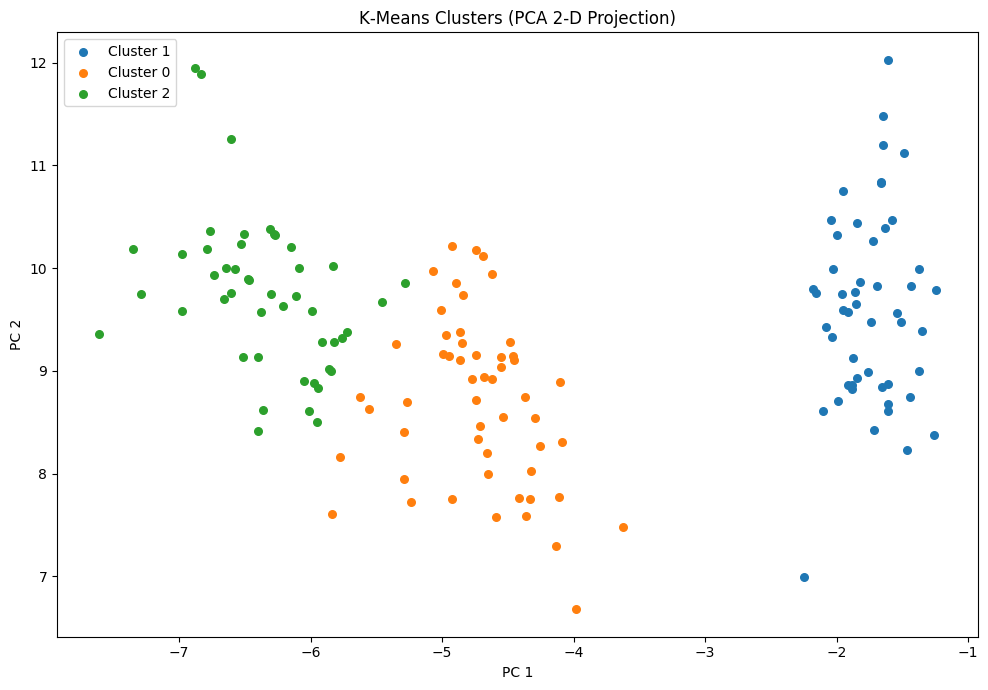

In [26]:
from matplotlib import pyplot as plt
import pandas as pd


plt.figure(figsize=(10, 7))
for cl in pca_df["cluster"].unique():
    sub = pca_df[pca_df["cluster"] == cl].reset_index(drop=True)
    sub[["PC1", "PC2"]] = pd.DataFrame(sub["pca2"].tolist())

    plt.scatter(sub["PC1"], sub["PC2"], label=f"Cluster {cl}", s=30)

plt.title("K‑Means Clusters (PCA 2‑D Projection)")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.legend()
plt.tight_layout()
plt.show()

In [27]:
spark.stop()